In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.pyplot import figure
import os
import numpy as np
import plot_helper as helper

In [2]:
in_path = "../output_spk_generalize/raw_score-v2_clean.csv"

skip_dims = [200, 400, 600, 768, 800, 1000]
# trainset = "clean460"

df = pd.read_csv(in_path)
df = df[ (df["concept"] == "spk") & (df["method"] != "EYE")]
df = df.map(lambda x: round(x*100,1) if type(x) == float else x)

for skip_dim_ in skip_dims:
    df = df[ df["method"] != f"LEACE-comp{skip_dim_}"]

reten_score = df["retention"].tolist()
leak_score = df["leakage"].tolist()
pur_score = df["purity"].tolist()
int_score = df["interference"].tolist()
# labels = df["method"]

In [3]:
df

,concept,method,mode,seed,retention,purity,leakage,interference
4,spk,WORST,clean,0,2.7,12.2,80.0,92.1
5,spk,BEST,clean,0,80.0,92.1,2.7,12.2
7,spk,LEACE-comp40,clean,0,61.1,89.3,39.3,12.4
8,spk,LEACE-comp100,clean,0,70.3,84.1,23.4,12.6
10,spk,LEACE-comp300,clean,0,75.6,61.7,10.9,13.9
12,spk,LEACE-comp500,clean,0,77.6,32.0,6.7,17.0
14,spk,LEACE-comp700,clean,0,79.0,14.1,3.6,34.0


In [4]:
model2markers = helper.model2markers
model2markers = {
    **model2markers,
    "best case": "+"
}
model2color = {
    "standard": "C0",
    "overfit": "C1",
    "scale": helper.model2color["LEACE"],
    "best case": "black"
}

BOUNDARY_COLOR = "C7"
# BOUNDARY_LINESTYLES_WORST = "dashed"
# BOUNDARY_LINESTYLES_BEST = "dashed"
BOUNDARY_ALPHA = 0.7
BOUNDARY_LINESTYLES = "dashed"
BOUNDARY_LINE_WIDTH=1
FIG_SIZE=(2,2)
FIG_DPI=100
FONT_SIZE_BIG=11
FONT_SIZE_DEFAULT=9
MARKER_SIZE=100
MARKER_ALPHA = 0.8

matplotlib.rcParams.update({'font.size': FONT_SIZE_DEFAULT})

ARROW_COLOR = "black"
ARROW_TEXT = "better"

In [5]:
# output_dir = "outputs/spk_scale_exp_v5"
output_dir = "plots/spk_scale_exp_v5_reproduce"
os.makedirs(output_dir, exist_ok=True)

In [6]:
df

,concept,method,mode,seed,retention,purity,leakage,interference
4,spk,WORST,clean,0,2.7,12.2,80.0,92.1
5,spk,BEST,clean,0,80.0,92.1,2.7,12.2
7,spk,LEACE-comp40,clean,0,61.1,89.3,39.3,12.4
8,spk,LEACE-comp100,clean,0,70.3,84.1,23.4,12.6
10,spk,LEACE-comp300,clean,0,75.6,61.7,10.9,13.9
12,spk,LEACE-comp500,clean,0,77.6,32.0,6.7,17.0
14,spk,LEACE-comp700,clean,0,79.0,14.1,3.6,34.0


In [7]:
min_alpha, max_alpha = 0.25, 1.0
# gradients for the scale experiment
step_size = (max_alpha-min_alpha)/(len(df)-2)
color_gradients = np.arange(min_alpha, max_alpha, step_size)
# prepend alpha values for "best case", "standard", and "overfit"
color_gradients = np.concatenate([ [1, 1, 1], color_gradients[::-1]])
color_gradients

array([1.  , 1.  , 1.  , 0.85, 0.7 , 0.55, 0.4 , 0.25])

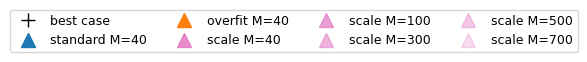

saved: plots/spk_scale_exp_v5_reproduce/legend.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_legend(labels, models, output_dir):    
    exp_names = [x_.split(" ")[0] if x_ != "best case" else x_ for x_ in labels ]
    empty_plot = lambda m,c,a: plt.plot([],[],marker=m, color=c, ls="none", markersize=MARKER_SIZE**0.5, alpha=a)[0]    
    fig_legend = plt.figure(figsize=(1, 0.5))
    handles = [empty_plot(model2markers[models[i]], model2color[exp_names[i]], color_gradients[i]) for i in range(len(exp_names))]
    legend = fig_legend.legend(handles, labels, loc='center', ncol=4, frameon=True, fontsize=FONT_SIZE_DEFAULT)
    fig_legend.gca().set_axis_off()
    fig_legend.tight_layout()
    fig_legend.savefig(os.path.join(output_dir, f"legend.png"), dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    print("saved:", os.path.join(output_dir, f"legend.png"))


leace_method_results = df[df["method"].map(lambda x: "LEACE" in x)]["method"]
ncomp_in_use = leace_method_results.map(lambda y: y.split("-comp")[1]).tolist()
labels = [
    "best case",
    "standard M=40",
    "overfit M=40",
    *[f"scale M={M}" for M in ncomp_in_use]
]
plot_legend(labels=labels, 
    models=[
        "BEST",
        "LEACE",
        "LEACE",
        *["LEACE" for M in ncomp_in_use]
    ],
        output_dir=output_dir)

In [9]:
labels

['best case',
 'standard M=40',
 'overfit M=40',
 'scale M=40',
 'scale M=100',
 'scale M=300',
 'scale M=500',
 'scale M=700']

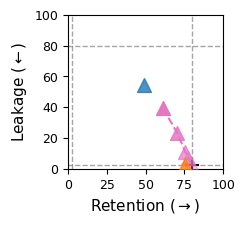

In [10]:
fig, ax = plt.subplots(1, 1, figsize=FIG_SIZE, dpi=FIG_DPI, sharey=True)
# BEST
ax.hlines(reten_score[0], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
ax.vlines(leak_score[0], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
# WORST
ax.hlines(reten_score[1], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
ax.vlines(leak_score[1], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)

ax.scatter(48.8, 54.4, label="standard M=40", marker=model2markers["LEACE"], s=MARKER_SIZE, zorder=10,  alpha=MARKER_ALPHA, color=model2color["standard"])
ax.scatter(75.6, 2.7, label="overfit M=40", marker=model2markers["LEACE"], s=MARKER_SIZE, zorder=10,  alpha=MARKER_ALPHA, color=model2color["overfit"])

# Add labels to each point
for i, method in enumerate(df["method"]):
    if "LEACE" in method:        
        alpha_ = color_gradients[i]         
        plt.scatter(reten_score[i], leak_score[i], color=model2color["scale"], marker=model2markers["LEACE"], 
                    s=MARKER_SIZE, alpha=alpha_, zorder=i,
                    label=f"scale M={method.split('-comp')[-1]}")
    elif "BEST" in method:
        plt.scatter(reten_score[i], leak_score[i], color=model2color["best case"], marker=model2markers["BEST"], 
                    s=MARKER_SIZE, alpha=1, zorder=-1,
                    label= f"best case")


ax.plot(reten_score[2:], leak_score[2:], "--", color=model2color["scale"])

# ax.annotate("", xytext=(5,35), xy=(35,5),
#             arrowprops=dict(
#                     arrowstyle="simple",
#                     color=ARROW_COLOR,
#                 ))
# ax.text(13, 13, ARROW_TEXT, rotation=-45, color=ARROW_COLOR)

ax.set_xlim([0, 100])
ax.set_ylim([0, 100])
ax.set_xlabel(r"Retention $(\rightarrow)$", fontsize=FONT_SIZE_BIG)
ax.set_ylabel(r"Leakage $(\leftarrow)$", fontsize=FONT_SIZE_BIG)
# plt.title("Speaker containment", fontsize=FONT_SIZE_BIG)
# plt.legend(loc=(-0.03, 1.1), ncol=3, markerscale=0.7, fontsize=FONT_SIZE_DEFAULT)
# plt.savefig(f"{output_dir}/legend.png", dpi=FIG_DPI,  bbox_inches="tight")
plt.savefig(f"{output_dir}/spk_containment_train460.png", dpi=FIG_DPI,  bbox_inches="tight")
plt.show()

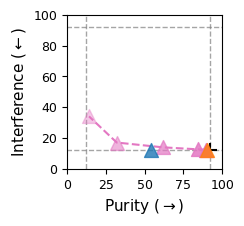

In [11]:
fig, ax = plt.subplots(1, 1, figsize=FIG_SIZE, dpi=FIG_DPI, sharey=True)
# BEST
ax.hlines(pur_score[0], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
ax.vlines(int_score[0], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
# WORST
ax.hlines(pur_score[1], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)
ax.vlines(int_score[1], -5, 105, color=BOUNDARY_COLOR, alpha=BOUNDARY_ALPHA, zorder=-5, linestyles=BOUNDARY_LINESTYLES, linewidth=BOUNDARY_LINE_WIDTH)

ax.scatter(54.4, 12.4, label="standard M=40", marker=model2markers["LEACE"], s=MARKER_SIZE, zorder=10, alpha=MARKER_ALPHA)
ax.scatter(90.0, 12.4, label="overfit M=40", marker=model2markers["LEACE"], s=MARKER_SIZE, zorder=10, alpha=MARKER_ALPHA)

# Add labels to each point
for i, method in enumerate(df["method"]):
    if "LEACE" in method:
        alpha_ = color_gradients[i]         
        ax.scatter(pur_score[i], int_score[i], color=model2color["scale"], marker=model2markers["LEACE"], 
                    s=MARKER_SIZE, alpha=alpha_, zorder=i,
                    label=f"scale M={method.split('-comp')[-1]}")
    elif "BEST" in method:
        plt.scatter(pur_score[i], int_score[i], color=model2color["best case"], marker=model2markers["BEST"], 
                    s=MARKER_SIZE, alpha=1, zorder=-1,
                    label= f"best case")

ax.plot(pur_score[2:], int_score[2:], "--", color=model2color["scale"])

# ax.annotate("", xytext=(65,90), xy=(90,65),
#             arrowprops=dict(
#                     arrowstyle="simple",
#                     color=ARROW_COLOR,
#                 ))
# ax.text(62, 62, ARROW_TEXT, rotation=-45, color=ARROW_COLOR)

ax.set_xlim([0, 100])
ax.set_ylim([0, 100])
ax.set_xlabel(r"Purity $(\rightarrow)$", fontsize=FONT_SIZE_BIG)
ax.set_ylabel(r"Interference $(\leftarrow)$", fontsize=FONT_SIZE_BIG)
# plt.title("Speaker containment", fontsize=FONT_SIZE_BIG))
# plt.legend(loc=(-0.03, 1.1), ncol=3, markerscale=0.7, fontsize=FONT_SIZE_DEFAULT)
plt.savefig(f"{output_dir}/spk_disentanglement_train460.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()